In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df_raw = pd.read_csv(r"C:\Users\USER\Desktop\AmlsoftwareRepo\AmLsoftwareRepo\maplefreight_delivery_delay_dataset.csv")
print(df_raw.shape)
df_raw.head()

(6035, 23)


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,num_stops,is_cross_border,scheduled_transit_hours,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,2,0,7.53,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,0,0,1.00,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,0,0,7.12,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,0,0,7.61,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,1,0,12.90,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


In [111]:
df_raw.info()

missing = df_raw.isna().sum()
print("\nMissing values:\n", missing[missing > 0])

print("\nExact duplicate rows:", df_raw.duplicated().sum())
print("Duplicate shipment IDs:", df_raw["shipment_id"].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6035 entries, 0 to 6034
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   shipment_id                6035 non-null   str    
 1   origin_city                6035 non-null   str    
 2   destination_city           6035 non-null   str    
 3   carrier                    6035 non-null   str    
 4   service_level              6035 non-null   str    
 5   goods_type                 6035 non-null   str    
 6   customer_priority_tier     6035 non-null   str    
 7   shipment_month             6035 non-null   int64  
 8   distance_km                6035 non-null   float64
 9   weight_kg                  6035 non-null   float64
 10  num_stops                  6035 non-null   int64  
 11  is_cross_border            6035 non-null   int64  
 12  scheduled_transit_hours    6035 non-null   float64
 13  pickup_delay_minutes       6035 non-null   float64
 14  dri

In [112]:
cat_cols = df_raw.select_dtypes(include=["object", "string"]).columns.drop("shipment_id")
for col in cat_cols:
    print(f"\n{col}:\n{df_raw[col].value_counts(dropna=False)}")

display(df_raw.describe().T)

print(df_raw["delivered_late"].value_counts(normalize=True).round(3))


origin_city:
origin_city
Toronto ON        1593
Mississauga ON    1019
Montreal QC       1017
Calgary AB         762
Ottawa ON          730
London ON          460
Winnipeg MB        454
Name: count, dtype: int64

destination_city:
destination_city
Sudbury ON        641
Toronto ON        638
Regina SK         634
Winnipeg MB       614
Hamilton ON       604
Quebec City QC    598
Edmonton AB       592
Montreal QC       587
Calgary AB        578
Ottawa ON         549
Name: count, dtype: int64

carrier:
carrier
MapleFreight Fleet    2391
NorthStar Carriers    1164
PrairieLine            932
QuebecExpress          924
Contract Owner-Op      624
Name: count, dtype: int64

service_level:
service_level
Standard    3219
Express     1442
Economy     1254
standard      74
express       27
economy       19
Name: count, dtype: int64

goods_type:
goods_type
General Freight    2974
Refrigerated        924
Fragile             895
Bulk                744
Hazardous           498
Name: count, dtype: int6

,count,mean,std,min,25%,50%,75%,max
shipment_month,6035.0,6.543662,3.448260,1.00,4.000,7.000,10.000,12.00
distance_km,6035.0,632.192742,319.246133,80.50,398.600,571.100,804.850,2556.70
weight_kg,6035.0,6928.251135,83755.149685,30.00,496.000,827.100,1286.300,2999300.00
num_stops,6035.0,2.477051,1.707457,0.00,1.000,2.000,4.000,5.00
is_cross_border,6035.0,0.113007,0.316628,0.00,0.000,0.000,0.000,1.00
scheduled_transit_hours,6035.0,10.500388,4.758576,1.00,7.060,9.850,13.175,37.40
pickup_delay_minutes,6035.0,20.367688,30.618617,-20.00,-6.000,18.000,41.000,146.00
driver_experience_years,5825.0,6.497648,4.659277,0.20,3.200,5.400,8.600,35.00
vehicle_age_years,6035.0,5.489461,3.433676,0.10,3.000,4.800,7.200,20.00
traffic_index,5914.0,55.146365,17.592978,5.00,43.300,55.000,67.200,100.00


delivered_late
0    0.794
1    0.206
Name: proportion, dtype: float64


### Data understanding findings
- 6,035 rows, 23 columns; target `delivered_late` is ~21% positive → imbalanced.
- 32 exact duplicate rows, plus 3 duplicate IDs that differ only in `service_level` casing.
- `service_level` has inconsistent casing (e.g. "standard" vs "Standard").
- `weight_kg` max is ~3,000,000 → 40 rows appear to be recorded in grams.
- Missing values in `fuel_cost_cad`, `driver_experience_years`, `weather_condition`, `traffic_index`.
- `actual_transit_hours` is only known after delivery → **target leakage**, must be excluded from modelling.

In [113]:
df = df_raw.copy()

for col in cat_cols:
    df[col] = df[col].str.strip()
df["service_level"] = df["service_level"].str.title()   # only this column has casing issues

print(df["service_level"].value_counts())

service_level
Standard    3293
Express     1469
Economy     1273
Name: count, dtype: int64


In [114]:
before = len(df)
df = df.drop_duplicates()
print("Exact duplicates removed:", before - len(df))

remaining = df["shipment_id"].duplicated().sum()
print("Remaining duplicate IDs:", remaining)
df = df.drop_duplicates(subset="shipment_id", keep="first")
print("Rows now:", len(df))

Exact duplicates removed: 34
Remaining duplicate IDs: 1
Rows now: 6000


Rows recorded in grams: 40


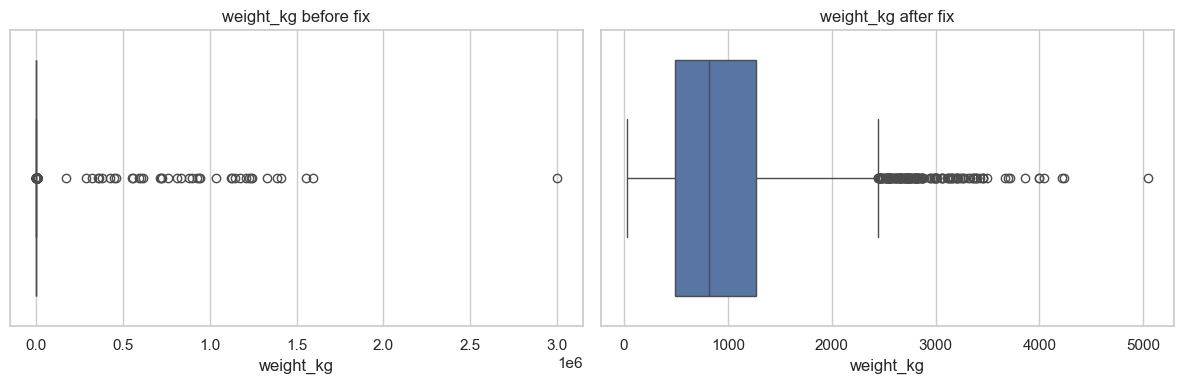

count    6000.0
mean      953.9
std       618.4
min        30.0
25%       494.6
50%       823.4
75%      1274.4
max      5044.0
Name: weight_kg, dtype: float64


In [115]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["weight_kg"], ax=ax[0]).set_title("weight_kg before fix")

grams_mask = df["weight_kg"] > 30_000   
print("Rows recorded in grams:", grams_mask.sum())
df.loc[grams_mask, "weight_kg"] = df.loc[grams_mask, "weight_kg"] / 1000

sns.boxplot(x=df["weight_kg"], ax=ax[1]).set_title("weight_kg after fix")
plt.tight_layout(); plt.show()
print(df["weight_kg"].describe().round(1))

In [116]:
same_city = df["origin_city"] == df["destination_city"]
print("Same-city shipments:", same_city.sum())
print(df.loc[same_city, "distance_km"].describe().round(1))
print("\nLate rate, same-city vs other:")
print(df.groupby(same_city)["delivered_late"].mean().round(3))

Same-city shipments: 465
count     465.0
mean      657.2
std       330.4
min        96.9
25%       411.2
50%       580.5
75%       833.7
max      2043.0
Name: distance_km, dtype: float64

Late rate, same-city vs other:
False    0.205
True     0.209
Name: delivered_late, dtype: float64


In [117]:
df["weather_condition"] = df["weather_condition"].fillna("Unknown")

print(df.isna().sum()[df.isna().sum() > 0])   # only numeric columns should remain
print("\nNegative distances:", (df["distance_km"] <= 0).sum())
print("Traffic index out of 0–100:", ((df["traffic_index"] < 0) | (df["traffic_index"] > 100)).sum())
print("Final shape:", df.shape)

driver_experience_years    210
traffic_index              120
fuel_cost_cad              240
dtype: int64

Negative distances: 0
Traffic index out of 0–100: 0
Final shape: (6000, 23)


## Exploratory data analysis
Goal: identify which shipment, route, carrier and condition factors are associated with late delivery.

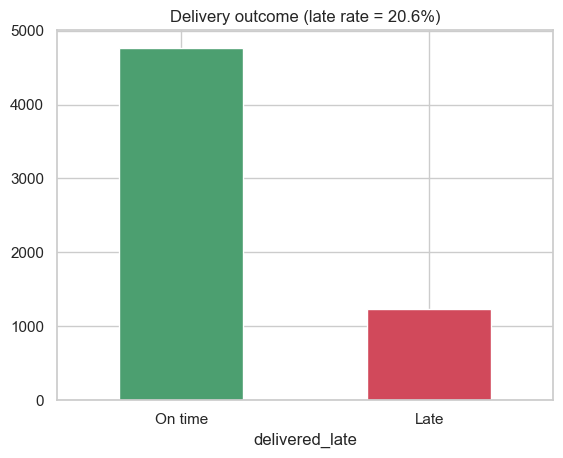

In [118]:
ax = df["delivered_late"].value_counts().plot(kind="bar", color=["#4C9F70", "#D1495B"])
ax.set_xticklabels(["On time", "Late"], rotation=0)
ax.set_title(f"Delivery outcome (late rate = {df['delivered_late'].mean():.1%})")
plt.show()

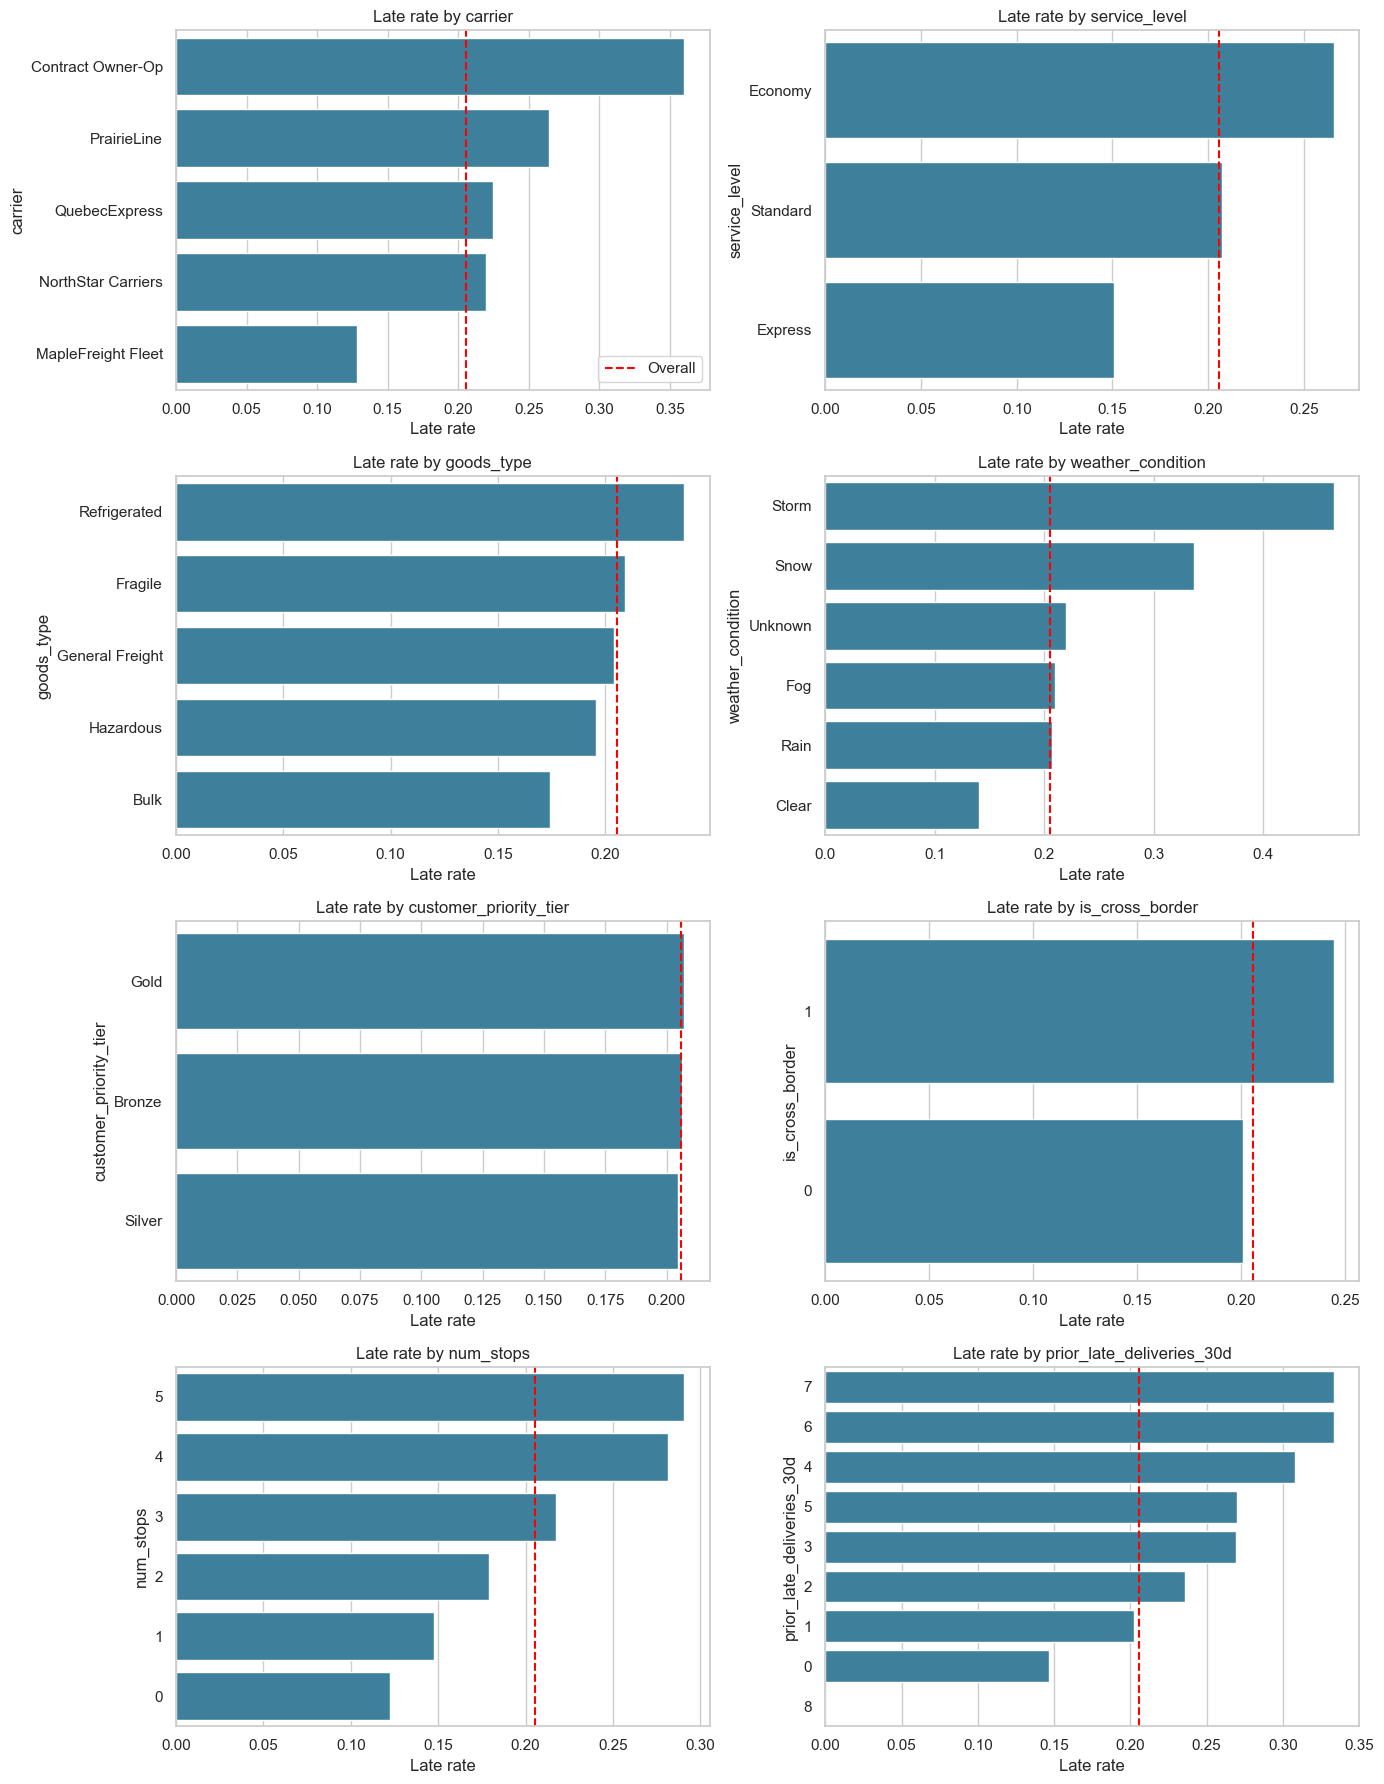

In [119]:
cat_features = ["carrier", "service_level", "goods_type", "weather_condition",
                "customer_priority_tier", "is_cross_border", "num_stops",
                "prior_late_deliveries_30d"]
overall = df["delivered_late"].mean()

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, col in zip(axes.flat, cat_features):
    rates = df.groupby(col)["delivered_late"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index.astype(str), ax=ax, color="#2E86AB")
    ax.axvline(overall, ls="--", color="red", label="Overall")
    ax.set_title(f"Late rate by {col}"); ax.set_xlabel("Late rate")
axes.flat[0].legend()
plt.tight_layout(); plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_28740\3038762311.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["On time", "Late"]); ax.set_xlabel("")
C:\Users\USER\AppData\Local\Temp\ipykernel_28740\3038762311.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["On time", "Late"]); ax.set_xlabel("")
C:\Users\USER\AppData\Local\Temp\ipykernel_28740\3038762311.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["On time", "Late"]); ax.set_xlabel("")
C:\Users\USER\AppData\Local\Temp\ipykernel_28740\3038762311.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["On time", "Late"])

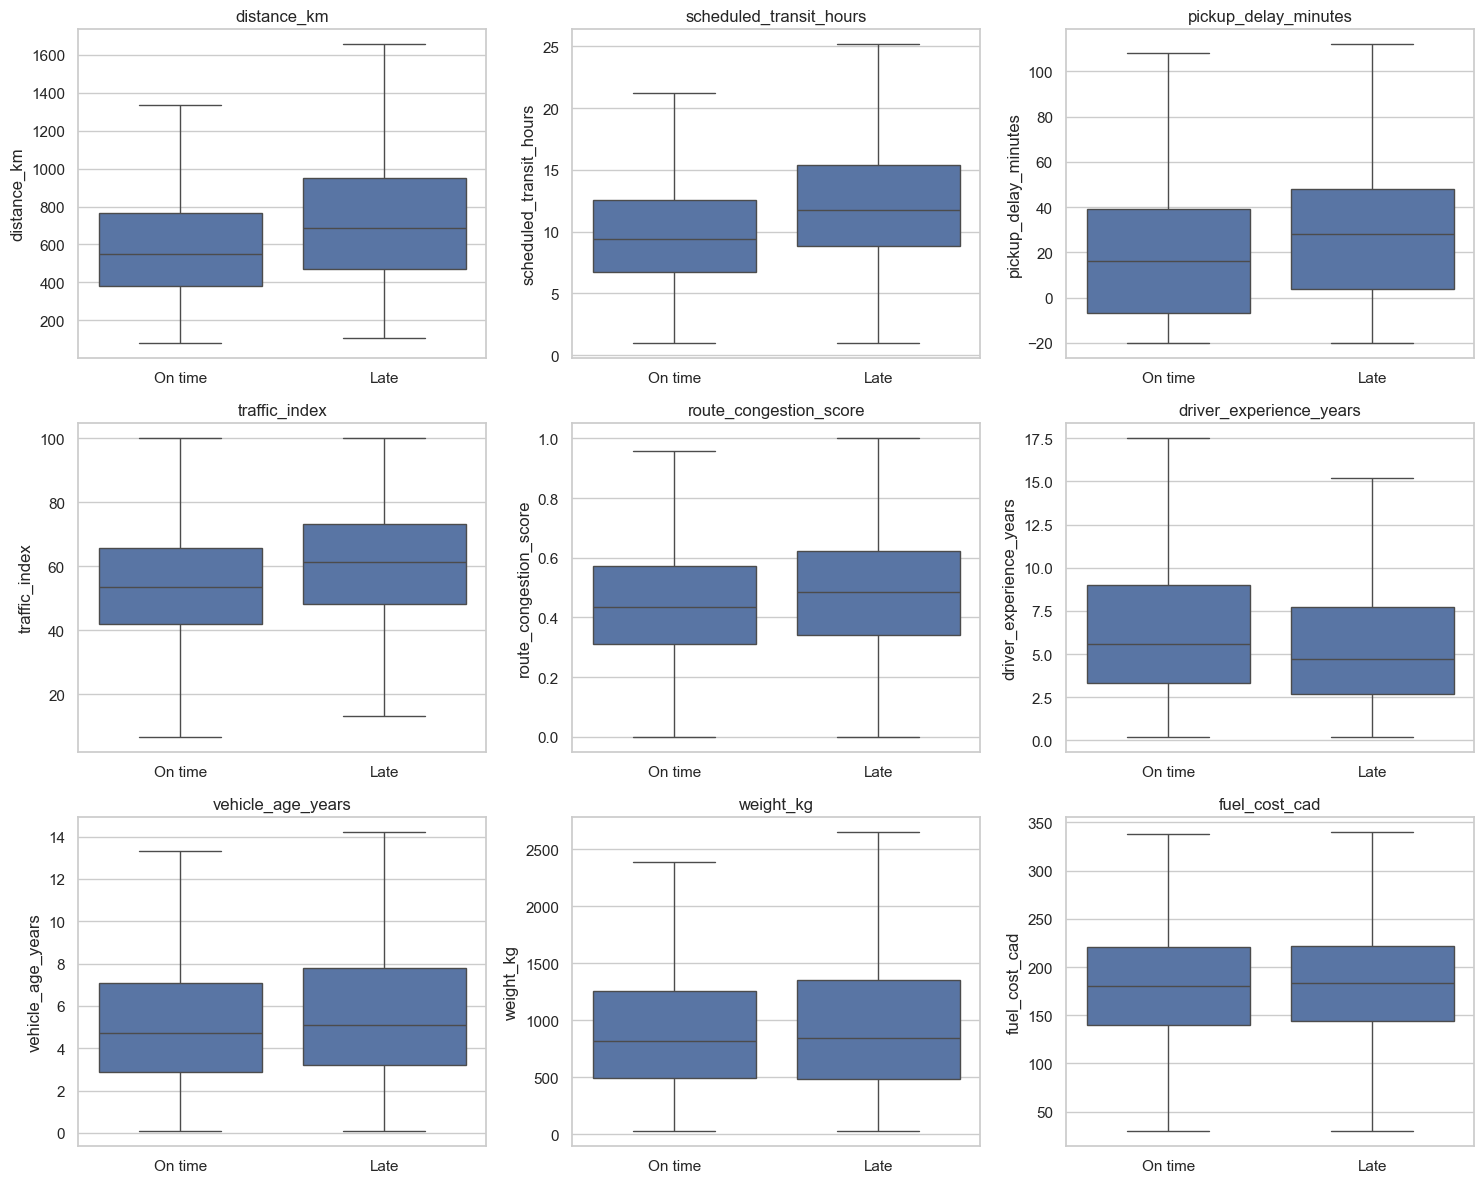

In [120]:
num_features = ["distance_km", "scheduled_transit_hours", "pickup_delay_minutes",
                "traffic_index", "route_congestion_score", "driver_experience_years",
                "vehicle_age_years", "weight_kg", "fuel_cost_cad"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, num_features):
    sns.boxplot(data=df, x="delivered_late", y=col, ax=ax, showfliers=False)
    ax.set_xticklabels(["On time", "Late"]); ax.set_xlabel("")
    ax.set_title(col)
plt.tight_layout(); plt.show()

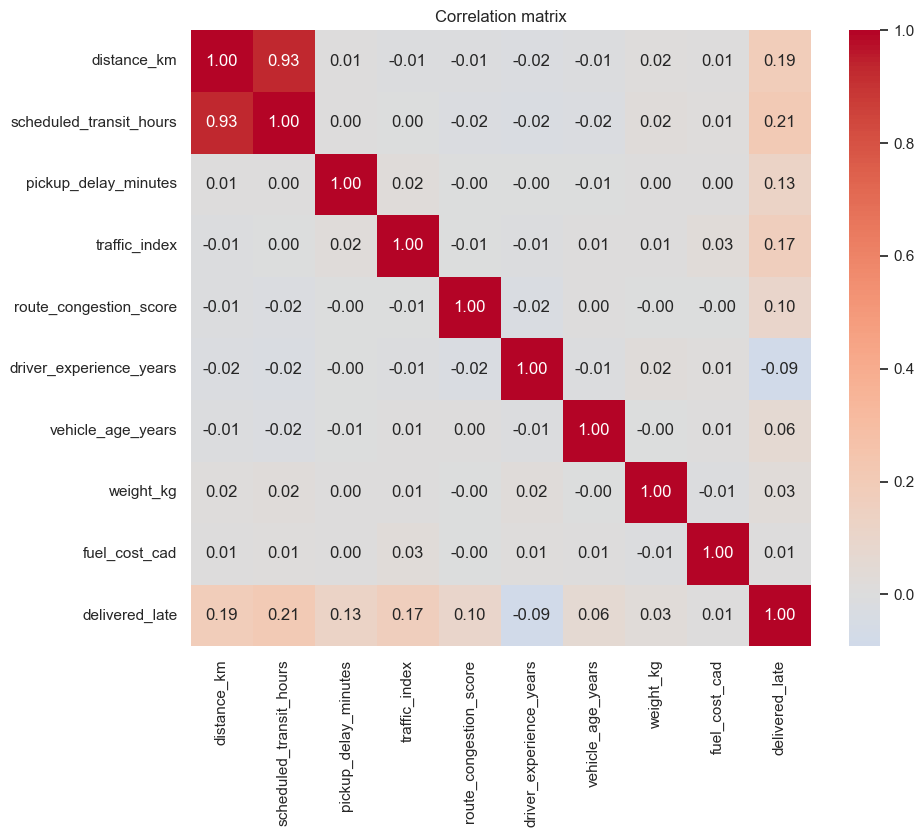

In [121]:
corr = df[num_features + ["delivered_late"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix"); plt.show()

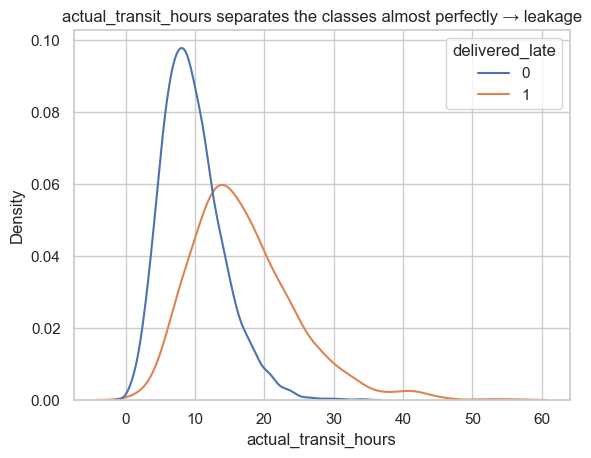

delivered_late
0     9.7
1    17.0
Name: actual_transit_hours, dtype: float64


In [122]:
sns.kdeplot(data=df, x="actual_transit_hours", hue="delivered_late", common_norm=False)
plt.title("actual_transit_hours separates the classes almost perfectly → leakage")
plt.show()
print(df.groupby("delivered_late")["actual_transit_hours"].mean().round(1))

## Feature engineering
All features  known **at dispatch time**, since the model scores in-transit shipments.
New features turn EDA patterns into explicit signals the model can use.

In [123]:
df_fe = df.copy()

df_fe["severe_weather"]   = df_fe["weather_condition"].isin(["Snow", "Storm"]).astype(int)
df_fe["new_driver"]       = (df_fe["driver_experience_years"] < 2).astype(int)
df_fe["late_pickup"]      = (df_fe["pickup_delay_minutes"] > 0).astype(int)
df_fe["long_haul"]        = (df_fe["distance_km"] > 800).astype(int)
df_fe["winter"]           = df_fe["shipment_month"].isin([12, 1, 2, 3]).astype(int)
df_fe["carrier_recent_issues"] = (df_fe["prior_late_deliveries_30d"] >= 3).astype(int)

new_feats = ["severe_weather", "new_driver", "late_pickup", "long_haul",
             "winter", "carrier_recent_issues"]
summary = pd.DataFrame({
    f: df_fe.groupby(f)["delivered_late"].mean() for f in new_feats
}).T.rename(columns={0: "late_rate_if_0", 1: "late_rate_if_1"}).round(3)
summary

,late_rate_if_0,late_rate_if_1
severe_weather,0.167,0.368
new_driver,0.199,0.256
late_pickup,0.146,0.232
long_haul,0.169,0.313
winter,0.194,0.229
carrier_recent_issues,0.194,0.279


In [124]:
from sklearn.model_selection import train_test_split

target = "delivered_late"
drop_cols = ["shipment_id", "actual_transit_hours", target]

X = df_fe.drop(columns=drop_cols)
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "late rate", y_train.mean().round(3))
print("Test: ", X_test.shape,  "late rate", y_test.mean().round(3))

Train: (4800, 26) late rate 0.206
Test:  (1200, 26) late rate 0.206


## Preprocessing pipeline

In [125]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical = ["origin_city", "destination_city", "carrier", "service_level",
               "goods_type", "customer_priority_tier", "weather_condition"]
numeric = [c for c in X.columns if c not in categorical]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

print(f"{len(numeric)} numeric, {len(categorical)} categorical features")

19 numeric, 7 categorical features


In [126]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()   # ≈ 3.9

models = {
    "Dummy (all on time)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression (baseline)": LogisticRegression(
        max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=5, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=600, max_depth=3, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
        eval_metric="logloss", random_state=RANDOM_STATE),
}

In [127]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]

cv_rows = []
for name, model in models.items():
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    cv_rows.append({"model": name, **{m: scores[f"test_{m}"].mean() for m in scoring}})

cv_results = pd.DataFrame(cv_rows).set_index("model").round(3)
cv_results.rename(columns={"average_precision": "pr_auc"})

c:\python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricW

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Dummy (all on time),0.794,0.000,0.000,0.000,0.500,0.206
Logistic Regression (baseline),0.735,0.417,0.723,0.529,0.809,0.561
Random Forest,0.817,0.582,0.411,0.480,0.795,0.531
XGBoost,0.751,0.433,0.670,0.526,0.802,0.548


===== Logistic Regression (baseline) =====
              precision    recall  f1-score   support

     On time      0.922     0.758     0.832       953
        Late      0.446     0.753     0.560       247

    accuracy                          0.757      1200
   macro avg      0.684     0.755     0.696      1200
weighted avg      0.824     0.757     0.776      1200

ROC-AUC: 0.833 | PR-AUC: 0.607

===== Random Forest =====
              precision    recall  f1-score   support

     On time      0.859     0.913     0.885       953
        Late      0.556     0.421     0.479       247

    accuracy                          0.812      1200
   macro avg      0.707     0.667     0.682      1200
weighted avg      0.797     0.812     0.802      1200

ROC-AUC: 0.821 | PR-AUC: 0.551

===== XGBoost =====
              precision    recall  f1-score   support

     On time      0.916     0.783     0.844       953
        Late      0.464     0.725     0.566       247

    accuracy                 

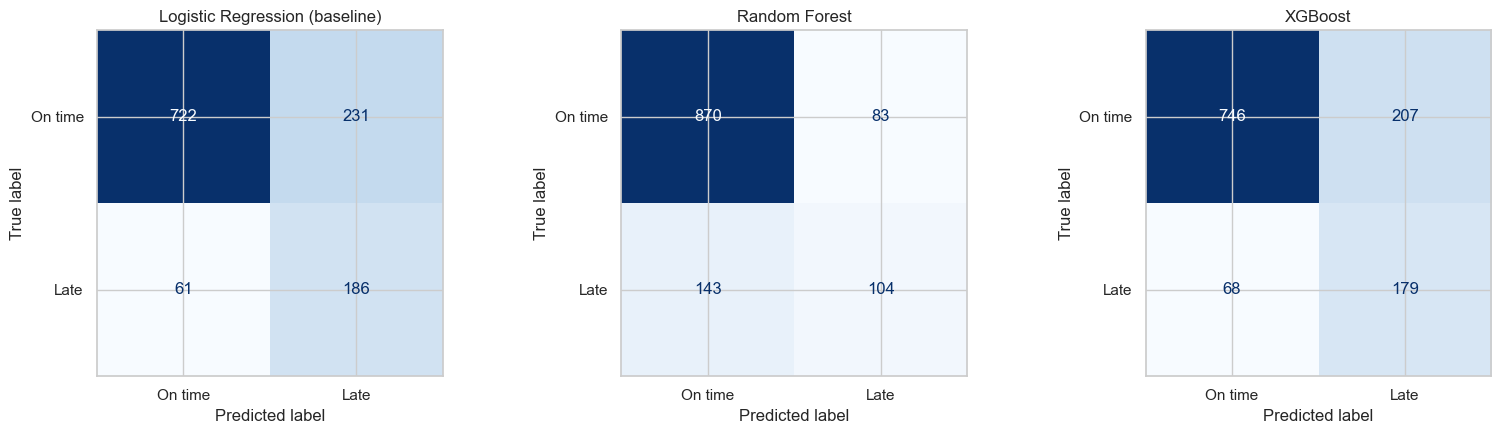

In [128]:
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_auc_score, average_precision_score)

fitted = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, name in zip(axes, list(models)[1:]):        # skip dummy
    pipe = Pipeline([("pre", preprocessor), ("model", models[name])]).fit(X_train, y_train)
    fitted[name] = pipe
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["On time", "Late"], digits=3))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f} | "
          f"PR-AUC: {average_precision_score(y_test, y_proba):.3f}\n")

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["On time", "Late"], ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

In [129]:
final_name = cv_results["average_precision"].idxmax()
final_model = fitted[final_name]
print("Selected model:", final_name)

Selected model: Logistic Regression (baseline)


## Model evaluation & threshold selection
The 0.5 default threshold is arbitrary. We choose the alert threshold using
**out-of-fold predictions on the training set** (not the test set), balancing:
- **Cost of a missed delay** (false negative): service credit + expedited re-delivery + complaint.
- **Cost of a false alarm** (false positive): dispatcher time to check, possible unnecessary customer call.
- **Alert volume**: dispatch can only act on a limited number of alerts per day.

In [130]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

oof_proba = cross_val_predict(final_model, X_train, y_train, cv=cv,
                              method="predict_proba")[:, 1]

thresholds = np.round(np.arange(0.30, 0.91, 0.05), 2)
rows = []
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": precision_score(y_train, pred),
                 "recall": recall_score(y_train, pred),
                 "f1": f1_score(y_train, pred),
                 "flag_rate": pred.mean(),
                 "alerts_per_week": int(pred.mean() * 8000)})
thr_table = pd.DataFrame(rows).round(3)
thr_table

,threshold,precision,recall,f1,flag_rate,alerts_per_week
0,0.30,0.317,0.889,0.467,0.577,4616
1,0.35,0.341,0.857,0.488,0.517,4133
2,0.40,0.367,0.814,0.506,0.456,3648
3,0.45,0.389,0.774,0.518,0.409,3270
4,0.50,0.417,0.723,0.529,0.356,2851
5,0.55,0.449,0.672,0.538,0.308,2460
6,0.60,0.473,0.611,0.533,0.265,2123
7,0.65,0.517,0.553,0.535,0.220,1760
8,0.70,0.549,0.478,0.511,0.179,1433
9,0.75,0.588,0.401,0.477,0.140,1123


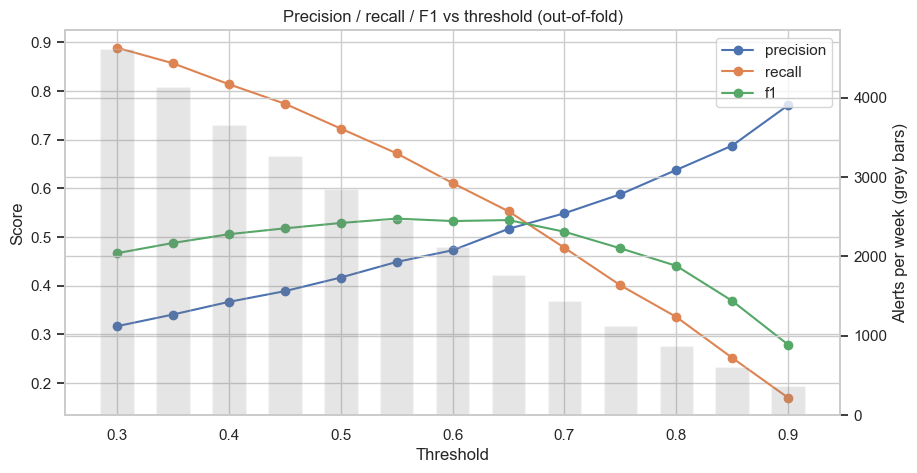

In [131]:
fig, ax1 = plt.subplots(figsize=(10, 5))
for m in ["precision", "recall", "f1"]:
    ax1.plot(thr_table["threshold"], thr_table[m], marker="o", label=m)
ax1.set_xlabel("Threshold"); ax1.set_ylabel("Score")

ax2 = ax1.twinx()
ax2.bar(thr_table["threshold"], thr_table["alerts_per_week"], width=0.03, alpha=0.2, color="grey")
ax2.set_ylabel("Alerts per week (grey bars)")
ax1.legend(loc="upper right"); plt.title("Precision / recall / F1 vs threshold (out-of-fold)")
plt.show()

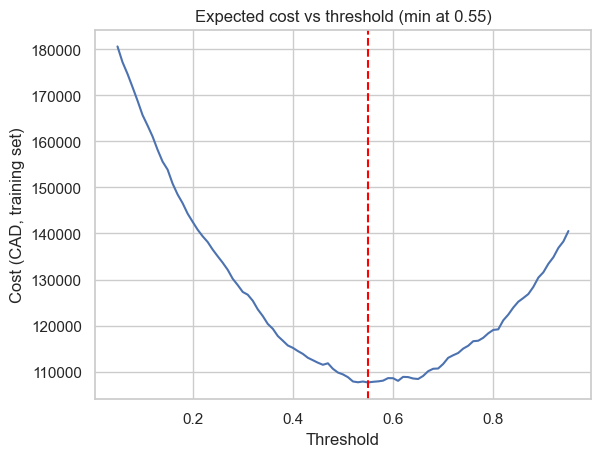

Cost-optimal threshold: 0.55 | F1-optimal threshold: 0.55


In [132]:
COST_MISSED_DELAY = 150   # service credit + expedited re-delivery (assumption)
COST_FALSE_ALARM  = 40    # ~20 min dispatcher time + possible unneeded customer call (assumption)

grid = np.arange(0.05, 0.96, 0.01)
costs = []
for t in grid:
    pred = oof_proba >= t
    fn = ((~pred) & (y_train == 1)).sum()
    alerts = pred.sum()                      # every alert gets checked, true or false
    costs.append(COST_MISSED_DELAY * fn + COST_FALSE_ALARM * alerts)

best_cost_t = grid[np.argmin(costs)]
best_f1_t = grid[np.argmax([f1_score(y_train, oof_proba >= t) for t in grid])]

plt.plot(grid, costs); plt.axvline(best_cost_t, ls="--", color="red")
plt.title(f"Expected cost vs threshold (min at {best_cost_t:.2f})")
plt.xlabel("Threshold"); plt.ylabel("Cost (CAD, training set)"); plt.show()
print(f"Cost-optimal threshold: {best_cost_t:.2f} | F1-optimal threshold: {best_f1_t:.2f}")

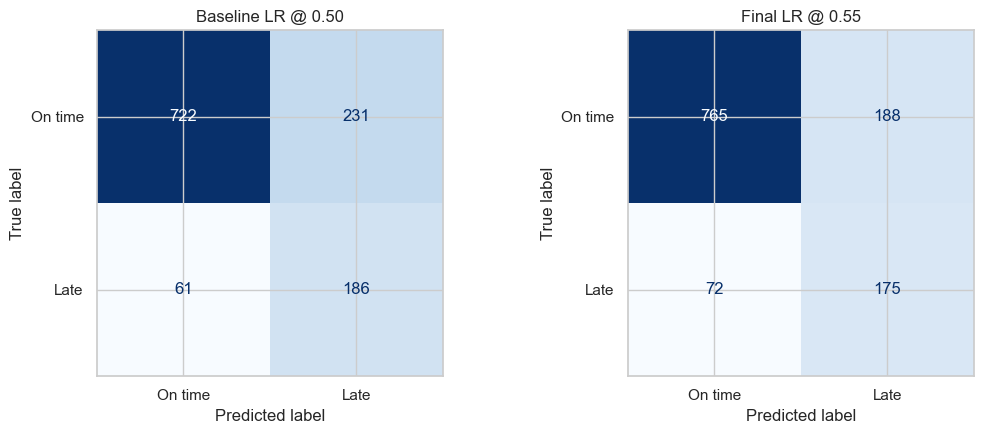

,precision,recall,f1,alerts_per_week
model,,,,
Baseline LR @ 0.50,0.446,0.753,0.560,2780
Final LR @ 0.55,0.482,0.709,0.574,2420


In [133]:
ALERT_THRESHOLD = 0.55    # set to your chosen value

test_proba = final_model.predict_proba(X_test)[:, 1]

comparison = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (label, t) in zip(axes, [("Baseline LR @ 0.50", 0.50),
                                 (f"Final LR @ {ALERT_THRESHOLD}", ALERT_THRESHOLD)]):
    pred = (test_proba >= t).astype(int)
    comparison.append({"model": label,
                       "precision": precision_score(y_test, pred),
                       "recall": recall_score(y_test, pred),
                       "f1": f1_score(y_test, pred),
                       "alerts_per_week": int(pred.mean() * 8000)})
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["On time", "Late"],
                                            ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(label)
plt.tight_layout(); plt.show()

pd.DataFrame(comparison).set_index("model").round(3)

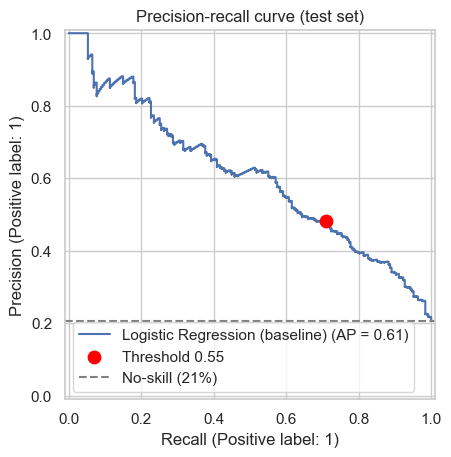

In [134]:
from sklearn.metrics import PrecisionRecallDisplay

disp = PrecisionRecallDisplay.from_predictions(y_test, test_proba, name=final_name)
pt = test_proba >= ALERT_THRESHOLD
disp.ax_.scatter(recall_score(y_test, pt), precision_score(y_test, pt),
                 color="red", s=80, zorder=3, label=f"Threshold {ALERT_THRESHOLD}")
disp.ax_.axhline(y_test.mean(), ls="--", color="grey", label="No-skill (21%)")
disp.ax_.legend(); plt.title("Precision-recall curve (test set)"); plt.show()

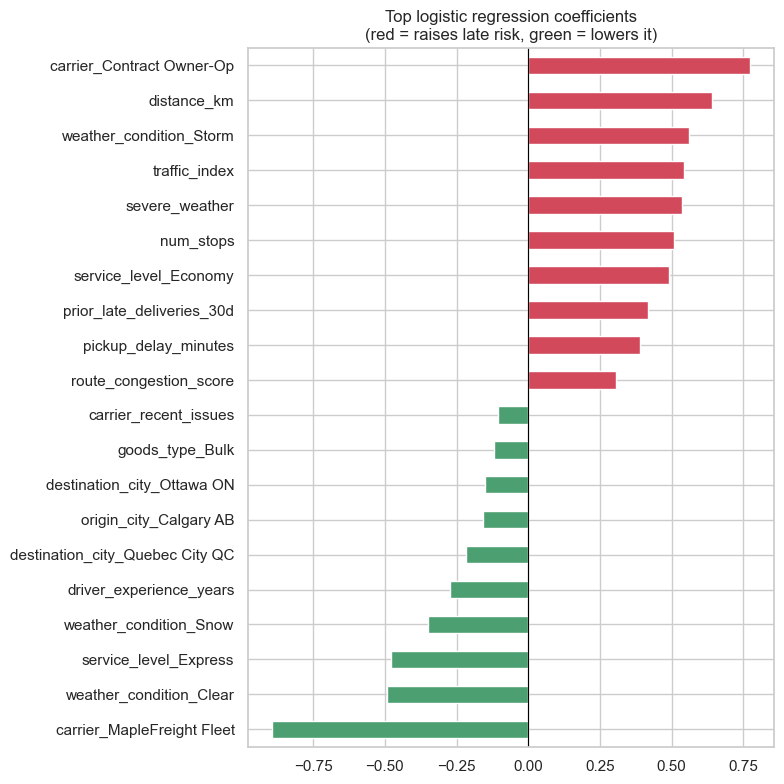

In [135]:
pre_fit = final_model.named_steps["pre"]
lr = final_model.named_steps["model"]

feat_names = [n.split("__", 1)[1] for n in pre_fit.get_feature_names_out()]
coefs = pd.Series(lr.coef_[0], index=feat_names).sort_values()

top = pd.concat([coefs.head(10), coefs.tail(10)])
plt.figure(figsize=(8, 8))
top.plot(kind="barh", color=["#4C9F70" if v < 0 else "#D1495B" for v in top])
plt.title("Top logistic regression coefficients\n(red = raises late risk, green = lowers it)")
plt.axvline(0, color="black", lw=0.8); plt.tight_layout(); plt.show()

In [136]:
try:
    import shap
except ModuleNotFoundError:
    %pip install shap
    import shap

Background dataset has 4800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4800 when initializing the masker.


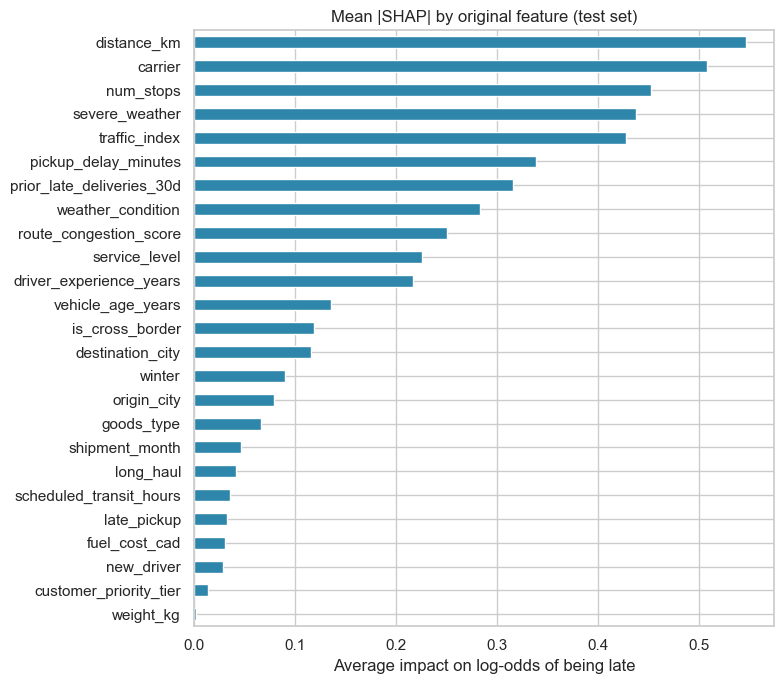

In [137]:



def to_dense(m):
    return m.toarray() if hasattr(m, "toarray") else m

Xtr_t = to_dense(pre_fit.transform(X_train))
Xte_t = to_dense(pre_fit.transform(X_test))

explainer = shap.LinearExplainer(lr, Xtr_t)
shap_vals = explainer.shap_values(Xte_t)

# map each encoded column back to its original feature
def original_feature(name):
    for c in categorical:
        if name.startswith(c + "_"):
            return c
    return name

groups = [original_feature(n) for n in feat_names]
shap_grouped = pd.DataFrame(shap_vals, columns=feat_names, index=X_test.index) \
                 .T.groupby(groups).sum().T

importance = shap_grouped.abs().mean().sort_values()
plt.figure(figsize=(8, 7))
importance.plot(kind="barh", color="#2E86AB")
plt.title("Mean |SHAP| by original feature (test set)")
plt.xlabel("Average impact on log-odds of being late")
plt.tight_layout(); plt.show()

In [138]:
import os

try:
    from dotenv import load_dotenv
except ModuleNotFoundError:
    %pip install python-dotenv
    from dotenv import load_dotenv

load_dotenv(override=True)   # override so an edited .env is picked up without a kernel restart

SLACK_WEBHOOK_URL = os.getenv("SLACK_WEBHOOK_URL")

if SLACK_WEBHOOK_URL:
    print("Webhook loaded:", True)
else:
    print("No Slack webhook configured; skipping alert.")

Webhook loaded: True


In [139]:
# --- Per-shipment risk factors (linear contributions = SHAP values for a linear model) ---
pre_fit = final_model.named_steps["pre"]
lr = final_model.named_steps["model"]

def to_dense(m):
    return m.toarray() if hasattr(m, "toarray") else m

feat_names = [n.split("__", 1)[1] for n in pre_fit.get_feature_names_out()]
Xtr_t = to_dense(pre_fit.transform(X_train))
Xte_t = to_dense(pre_fit.transform(X_test))

contrib = (Xte_t - Xtr_t.mean(axis=0)) * lr.coef_[0]

def original_feature(name):
    for c in categorical:
        if name.startswith(c + "_"):
            return c
    return name

contrib_grouped = (pd.DataFrame(contrib, columns=feat_names, index=X_test.index)
                     .T.groupby([original_feature(n) for n in feat_names]).sum().T)

def top_reasons(idx, n=2):
    row = contrib_grouped.loc[idx]
    return ", ".join(row[row > 0].sort_values(ascending=False).head(n).index)

# --- Risk table and alerts ---
risk = pd.DataFrame({
    "shipment_id": df_fe.loc[X_test.index, "shipment_id"],
    "risk_score": final_model.predict_proba(X_test)[:, 1],
}, index=X_test.index).join(
    df_fe.loc[X_test.index, ["destination_city", "carrier", "service_level"]]
)
risk["top_reasons"] = [top_reasons(i) for i in risk.index]

alerts = risk[risk["risk_score"] >= ALERT_THRESHOLD].sort_values("risk_score", ascending=False)
print(f"{len(alerts)} of {len(risk)} shipments at or above threshold {ALERT_THRESHOLD}")
alerts.head(10)

363 of 1200 shipments at or above threshold 0.55


,shipment_id,risk_score,destination_city,carrier,service_level,top_reasons
5295,SHP-100936,0.987938,Calgary AB,PrairieLine,Standard,"distance_km, severe_weather"
1557,SHP-103230,0.977665,Regina SK,Contract Owner-Op,Standard,"severe_weather, carrier"
3048,SHP-105511,0.976566,Ottawa ON,NorthStar Carriers,Express,"traffic_index, severe_weather"
2112,SHP-102910,0.975386,Edmonton AB,QuebecExpress,Economy,"severe_weather, distance_km"
956,SHP-101710,0.975030,Sudbury ON,MapleFreight Fleet,Standard,"distance_km, severe_weather"
3645,SHP-100273,0.973440,Hamilton ON,NorthStar Carriers,Standard,"distance_km, severe_weather"
554,SHP-103300,0.971278,Winnipeg MB,NorthStar Carriers,Standard,"severe_weather, pickup_delay_minutes"
940,SHP-101673,0.969403,Sudbury ON,Contract Owner-Op,Standard,"severe_weather, carrier"
1483,SHP-104995,0.966163,Winnipeg MB,NorthStar Carriers,Standard,"severe_weather, traffic_index"
268,SHP-105927,0.961936,Calgary AB,QuebecExpress,Economy,"severe_weather, traffic_index"


In [140]:
def build_message(alerts, total, top_n=5):
    lines = [
        f":rotating_light: *{len(alerts)} of {total} in-transit shipments at risk of late delivery*",
        f"Threshold: {ALERT_THRESHOLD:.0%} risk  •  Showing top {min(top_n, len(alerts))}",
        "",
    ]
    for _, r in alerts.head(top_n).iterrows():
        lines.append(
            f"*{r['shipment_id']}*  →  {r['destination_city']}\n"
            f"      {r['carrier']}  •  Risk *{r['risk_score']:.0%}*\n"
            f"      _Why: {r['top_reasons'].replace('_', ' ')}_"
        )
    lines.append("\nAction: review top shipments for re-routing or proactive customer notice.")
    return "\n".join(lines)

message = build_message(alerts, total=len(risk))
print(message)

:rotating_light: *363 of 1200 in-transit shipments at risk of late delivery*
Threshold: 55% risk  •  Showing top 5

*SHP-100936*  →  Calgary AB
      PrairieLine  •  Risk *99%*
      _Why: distance km, severe weather_
*SHP-103230*  →  Regina SK
      Contract Owner-Op  •  Risk *98%*
      _Why: severe weather, carrier_
*SHP-105511*  →  Ottawa ON
      NorthStar Carriers  •  Risk *98%*
      _Why: traffic index, severe weather_
*SHP-102910*  →  Edmonton AB
      QuebecExpress  •  Risk *98%*
      _Why: severe weather, distance km_
*SHP-101710*  →  Sudbury ON
      MapleFreight Fleet  •  Risk *98%*
      _Why: distance km, severe weather_

Action: review top shipments for re-routing or proactive customer notice.


In [141]:
import requests

def send_slack_alert(text, webhook_url):
    if not webhook_url:
        print("No SLACK_WEBHOOK_URL found, skipping send.")
        return False
    resp = requests.post(webhook_url, json={"text": text}, timeout=10)
    if resp.status_code == 200:
        print("Slack alert sent ✅")
        return True
    raise RuntimeError(f"Slack error {resp.status_code}: {resp.text} "
                       "(check SLACK_WEBHOOK_URL in .env; regenerate it if the app was removed)")

alerts_df = globals().get("alerts", pd.DataFrame())
message_text = globals().get("message")

if len(alerts_df) > 0 and message_text:
    send_slack_alert(message_text, SLACK_WEBHOOK_URL)
else:
    print("No high-risk shipments or alert message available; no alert sent.")

Slack alert sent ✅


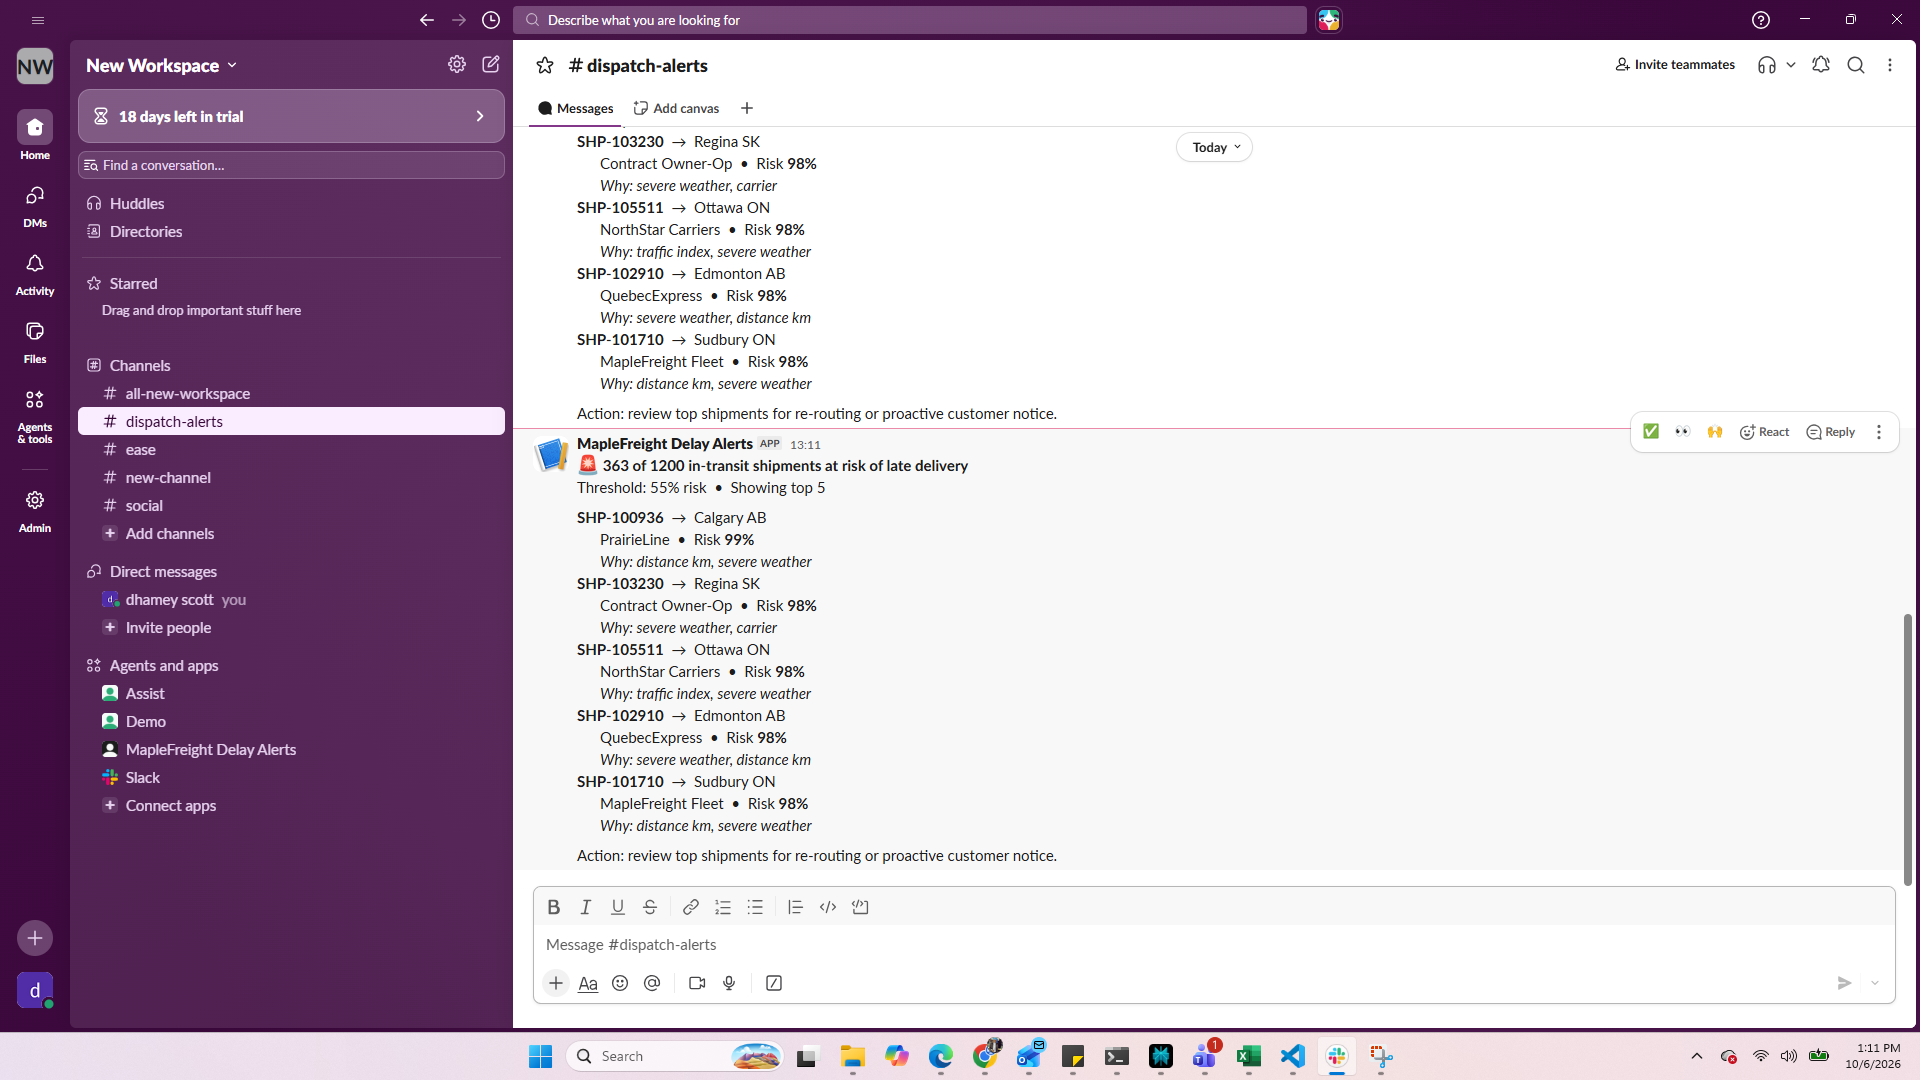
![Slack alert](screenshots/slack_alert.png)